# Presentation Assets for Final Pipeline

`data/doraemong.jpeg`를 대상으로 발표용 이미지를 생성합니다. 결과는 `presentation/` 폴더에 저장됩니다.

In [1]:
import os
import sys
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

sys.path.append("src")
import importlib
import coloringbook_utils as coloringbook_utils
importlib.reload(coloringbook_utils)
from coloringbook_utils import *

IMAGE_PATH = "data/doraemong.jpeg"
PRESENTATION_DIR = Path("presentation")
PRESENTATION_DIR.mkdir(exist_ok=True)

K = 30
K_VALUES = [10, 30, 50]
CANNY_LOW = 80
CANNY_HIGH = 180
COLOR_EDGE_DELTA = 35
OBJECT_MIN_AREA = 260
OBJECT_CLOSE_KERNEL = 5
DETAIL_CANNY_LOW = 90
DETAIL_CANNY_HIGH = 200
DETAIL_MIN_AREA = 3
DETAIL_MAX_AREA = 1200
DARK_DETAIL_THRESHOLD = 70
DARK_DETAIL_MIN_AREA = 5
DARK_DETAIL_MAX_AREA = 900
LINE_THICKNESS = 1
MIN_REGION_AREA = 160
SIMPLIFY_DIAMETER = 9
SIMPLIFY_SIGMA_COLOR = 90
SIMPLIFY_SIGMA_SPACE = 90

image = load_image(IMAGE_PATH)
print(f"Loaded: {IMAGE_PATH}, shape={image.shape}")

Loaded: data/doraemong.jpeg, shape=(512, 519, 3)


In [2]:
def object_first_edges(label_map, min_area=260, close_kernel=5, thickness=1):
    labels = np.asarray(label_map, dtype=np.int32)
    edge = np.zeros(labels.shape, dtype=np.uint8)
    kernel = np.ones((close_kernel, close_kernel), np.uint8)

    for label_id in np.unique(labels):
        mask = (labels == label_id).astype(np.uint8) * 255
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            if cv2.contourArea(contour) < min_area:
                continue
            cv2.drawContours(edge, [contour], -1, 255, thickness, cv2.LINE_8)
    return edge


def thin_binary_edges(edges):
    img = (edges > 0).astype(np.uint8)
    changed = True
    while changed:
        changed = False
        for step in (0, 1):
            padded = np.pad(img, 1, mode="constant")
            marker = np.zeros_like(img)
            for y in range(1, padded.shape[0] - 1):
                for x in range(1, padded.shape[1] - 1):
                    if padded[y, x] == 0:
                        continue
                    p2 = padded[y - 1, x]
                    p3 = padded[y - 1, x + 1]
                    p4 = padded[y, x + 1]
                    p5 = padded[y + 1, x + 1]
                    p6 = padded[y + 1, x]
                    p7 = padded[y + 1, x - 1]
                    p8 = padded[y, x - 1]
                    p9 = padded[y - 1, x - 1]
                    neighbors = [p2, p3, p4, p5, p6, p7, p8, p9]
                    count = sum(neighbors)
                    transitions = sum((neighbors[i] == 0 and neighbors[(i + 1) % 8] == 1) for i in range(8))
                    if not (2 <= count <= 6 and transitions == 1):
                        continue
                    if step == 0:
                        if p2 * p4 * p6 == 0 and p4 * p6 * p8 == 0:
                            marker[y - 1, x - 1] = 1
                    else:
                        if p2 * p4 * p8 == 0 and p2 * p6 * p8 == 0:
                            marker[y - 1, x - 1] = 1
            if np.any(marker):
                img[marker == 1] = 0
                changed = True
    return (img * 255).astype(np.uint8)


def detail_expression_edges(image, object_edges, low=100, high=220, min_area=8, max_area=450, dark_threshold=70, dark_min_area=5, dark_max_area=900):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    detail = cv2.Canny(gray, low, high)
    detail = cv2.bitwise_and(detail, cv2.bitwise_not(object_edges))
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(detail, 8)
    filtered_edges = np.zeros_like(detail)
    for i in range(1, n_labels):
        area = int(stats[i, cv2.CC_STAT_AREA])
        if min_area <= area <= max_area:
            filtered_edges[labels == i] = 255

    dark = (gray < dark_threshold).astype(np.uint8) * 255
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(dark, 8)
    filtered_dark = np.zeros_like(dark)
    for i in range(1, n_labels):
        area = int(stats[i, cv2.CC_STAT_AREA])
        if dark_min_area <= area <= dark_max_area:
            filtered_dark[labels == i] = 255
    return cv2.bitwise_or(filtered_edges, filtered_dark)


def border_connected_region_ids(region_map):
    if region_map.size == 0:
        return set()
    border_ids = np.concatenate([region_map[0, :], region_map[-1, :], region_map[:, 0], region_map[:, -1]])
    return set(int(v) for v in np.unique(border_ids) if int(v) > 0)


def best_label_point(region_map, region_id, bbox):
    x, y, w, h = bbox
    component = (region_map[y:y + h, x:x + w] == region_id).astype(np.uint8)
    if component.size == 0 or np.count_nonzero(component) == 0:
        return x + w / 2, y + h / 2
    dist = cv2.distanceTransform(component, cv2.DIST_L2, 5)
    _, _, _, max_loc = cv2.minMaxLoc(dist)
    return x + max_loc[0], y + max_loc[1]


def main_object_mask_from_regions(region_map, regions, background_ids, source_image=None, bridge_iterations=3):
    if source_image is not None:
        border = np.concatenate([source_image[0, :, :], source_image[-1, :, :], source_image[:, 0, :], source_image[:, -1, :]], axis=0)
        bg = np.median(border.reshape(-1, 3), axis=0)
        diff = np.linalg.norm(source_image.astype(np.float32) - bg.astype(np.float32), axis=2)
        gray_src = cv2.cvtColor(source_image, cv2.COLOR_RGB2GRAY)
        seed = ((diff > 28) | (gray_src < 120)).astype(np.uint8) * 255
        seed = cv2.morphologyEx(seed, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
        seed = cv2.morphologyEx(seed, cv2.MORPH_CLOSE, np.ones((17, 17), np.uint8), iterations=2)
        seed = cv2.dilate(seed, np.ones((5, 5), np.uint8), iterations=2)
        n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(seed, 8)
        if n_labels > 1:
            largest = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
            mask = (labels == largest).astype(np.uint8) * 255
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            filled = np.zeros_like(mask)
            if contours:
                cv2.drawContours(filled, contours, -1, 255, -1)
                filled = cv2.morphologyEx(filled, cv2.MORPH_CLOSE, np.ones((21, 21), np.uint8), iterations=1)
                return filled

    candidate = np.zeros(region_map.shape, dtype=np.uint8)
    for region in regions:
        region_id = int(region["id"])
        if region_id in background_ids:
            continue
        candidate[region_map == region_id] = 255
    if np.count_nonzero(candidate) == 0:
        return candidate
    bridge = cv2.dilate(candidate, np.ones((3, 3), np.uint8), iterations=bridge_iterations)
    bridge = cv2.morphologyEx(bridge, cv2.MORPH_CLOSE, np.ones((15, 15), np.uint8), iterations=1)
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(bridge, 8)
    if n_labels <= 1:
        return bridge
    largest = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
    mask = (labels == largest).astype(np.uint8) * 255
    mask = cv2.dilate(mask, np.ones((5, 5), np.uint8), iterations=1)
    return mask


def draw_paint_by_number_style(line_image, detail_edges, regions, region_map, background_ids, source_image=None, line_gray=185, text_gray=155, font_scale=0.42, use_object_mask=True):
    gray = cv2.cvtColor(line_image, cv2.COLOR_RGB2GRAY) if line_image.ndim == 3 else line_image
    if use_object_mask:
        keep_mask = main_object_mask_from_regions(region_map, regions, background_ids, source_image=source_image) > 0
    else:
        keep_mask = np.ones_like(gray, dtype=bool)
    edge_mask = ((gray < 128) | (detail_edges > 0)) & keep_mask
    canvas = np.full((gray.shape[0], gray.shape[1], 3), 255, dtype=np.uint8)
    canvas[edge_mask] = line_gray

    font = cv2.FONT_HERSHEY_SIMPLEX
    for region in sorted(regions, key=lambda r: r["area"], reverse=True):
        region_id = int(region["id"])
        if region_id in background_ids:
            continue
        if region["area"] < MIN_REGION_AREA:
            continue
        region_pixels = region_map == region_id
        if use_object_mask:
            object_overlap = np.count_nonzero(region_pixels & keep_mask)
            if object_overlap == 0 or object_overlap / max(1, int(region["area"])) < 0.45:
                continue
        text = str(region.get("color_id", region_id))
        cx, cy = best_label_point(region_map, region_id, region["bbox"])
        (tw, th), _ = cv2.getTextSize(text, font, font_scale, 1)
        x0, y0, w, h = region["bbox"]
        x = int(np.clip(cx - tw / 2, x0 + 1, max(x0 + 1, x0 + w - tw - 1)))
        y = int(np.clip(cy + th / 2, y0 + th + 1, max(y0 + th + 1, y0 + h - 1)))
        cv2.putText(canvas, text, (x, y), font, font_scale, (text_gray, text_gray, text_gray), 1, cv2.LINE_AA)
    return canvas


def save_named(name, img):
    path = PRESENTATION_DIR / name
    save_image_rgb(str(path), img)
    return path


def save_compare(name, items, cols=2, figsize=(10, 6), cmap=None):
    path = PRESENTATION_DIR / name
    show_images(items, cols=cols, figsize=figsize, cmap=cmap, save_path=str(path))
    return path

In [3]:
# Main pipeline for doraemong.jpeg
simplified_image = cv2.bilateralFilter(image, SIMPLIFY_DIAMETER, SIMPLIFY_SIGMA_COLOR, SIMPLIFY_SIGMA_SPACE)
kmeans_img, kmeans_palette, kmeans_labels = kmeans_quantization_with_labels(simplified_image, K)
poster_img, _ = posterization(simplified_image, K)
median_img, _ = median_cut_quantization(simplified_image, K)

sobel_clean = clean_edges(sobel_edges(kmeans_img, 65), open_iter=1, close_iter=1, thickness=1)
lap_clean = clean_edges(laplacian_edges(kmeans_img, 25), open_iter=1, close_iter=1, thickness=1)
canny_clean = clean_edges(canny_edges(kmeans_img, CANNY_LOW, CANNY_HIGH), open_iter=0, close_iter=1, thickness=2)

object_raw = object_first_edges(kmeans_labels, min_area=OBJECT_MIN_AREA, close_kernel=OBJECT_CLOSE_KERNEL, thickness=LINE_THICKNESS)
object_seg_clean = clean_edges(object_raw, open_iter=0, close_iter=1, thickness=2)
object_final_clean = thin_binary_edges(object_seg_clean)
detail_edges = detail_expression_edges(
    image,
    object_final_clean,
    low=DETAIL_CANNY_LOW,
    high=DETAIL_CANNY_HIGH,
    min_area=DETAIL_MIN_AREA,
    max_area=DETAIL_MAX_AREA,
    dark_threshold=DARK_DETAIL_THRESHOLD,
    dark_min_area=DARK_DETAIL_MIN_AREA,
    dark_max_area=DARK_DETAIL_MAX_AREA,
)

sobel_line = coloring_line_image(sobel_clean)
lap_line = coloring_line_image(lap_clean)
canny_line = coloring_line_image(canny_clean)
object_line = coloring_line_image(object_final_clean)
segmentation_line_image = coloring_line_image(object_seg_clean)
detail_line = coloring_line_image(detail_edges)
line_with_detail = object_line.copy()
line_with_detail[detail_edges > 0] = 0

region_map, regions = segment_connected_components(segmentation_line_image, MIN_REGION_AREA)
background_color = estimate_background_color(kmeans_img)
regions = assign_region_color_numbers(
    regions,
    region_map,
    kmeans_labels,
    kmeans_palette,
    background_color=background_color,
    background_color_threshold=16,
    merge_background_similar=True,
)
background_region_ids = border_connected_region_ids(region_map)
for region in regions:
    if int(region["id"]) in background_region_ids:
        region["is_background"] = True

region_preview = color_region_preview(region_map)
colored_by_labels = np.full_like(simplified_image, 255)
for region in regions:
    color = region.get("color_rgb")
    if color is not None:
        colored_by_labels[region_map == region["id"]] = np.array(color, dtype=np.uint8)
colored_by_labels[segmentation_line_image < 128] = 0
colored_by_labels_with_detail = colored_by_labels.copy()
colored_by_labels_with_detail[detail_edges > 0] = 0
colored_by_labels_numbered = label_regions(colored_by_labels_with_detail, regions, font_scale=0.65, region_map=region_map, skip_background=True)

before_noisy = draw_paint_by_number_style(object_line, detail_edges, regions, region_map, background_region_ids, source_image=simplified_image, use_object_mask=False)
after_clean = draw_paint_by_number_style(object_line, detail_edges, regions, region_map, background_region_ids, source_image=simplified_image, use_object_mask=True)
color_index = save_color_index_table(kmeans_palette, str(PRESENTATION_DIR / "slide06_color_index_table.png"), regions, "Doraemong Color Index")

print(f"regions={len(regions)}, background_regions={len(background_region_ids)}")

regions=80, background_regions=8


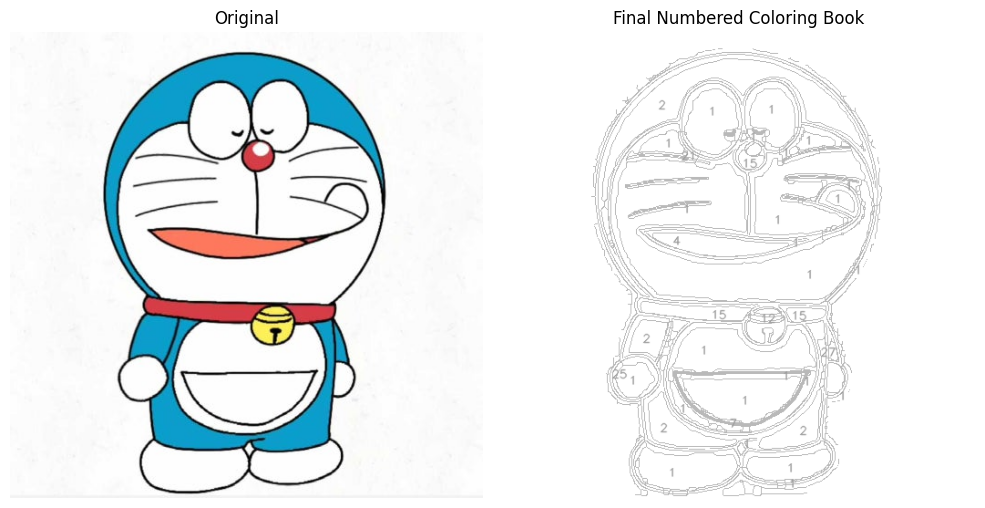

WindowsPath('presentation/slide01_title_before_after.png')

In [4]:
# Slide 01: title/final result
save_named("slide01_original.png", image)
save_named("slide01_final_numbered_coloringbook.png", after_clean)
save_compare(
    "slide01_title_before_after.png",
    [("Original", image), ("Final Numbered Coloring Book", after_clean)],
    cols=2,
    figsize=(10, 5),
)

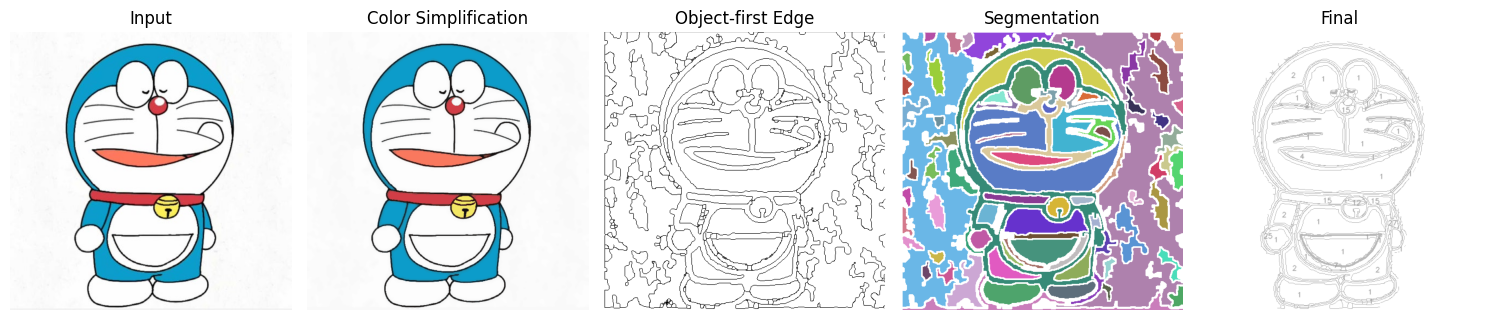

WindowsPath('presentation/slide02_pipeline_overview.png')

In [5]:
# Slide 02: 전체 파이프라인
save_named("slide02_01_input.png", image)
save_named("slide02_02_color_simplification.png", kmeans_img)
save_named("slide02_03_object_first_edge.png", object_line)
save_named("slide02_04_segmentation.png", region_preview)
save_named("slide02_05_final.png", after_clean)
save_compare(
    "slide02_pipeline_overview.png",
    [
        ("Input", image),
        ("Color Simplification", kmeans_img),
        ("Object-first Edge", object_line),
        ("Segmentation", region_preview),
        ("Final", after_clean),
    ],
    cols=5,
    figsize=(15, 3.5),
    cmap="gray",
)

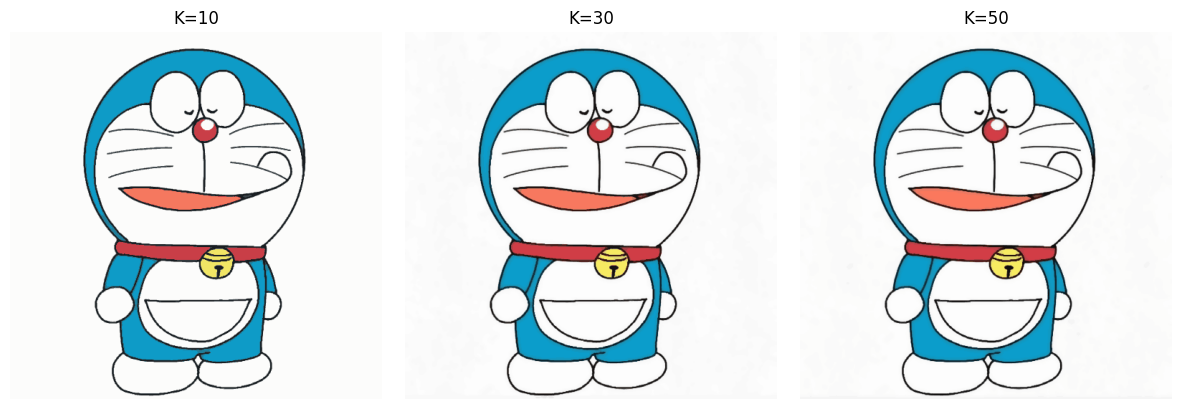

WindowsPath('presentation/slide03_color_tradeoff_k10_k30_k50.png')

In [6]:
# Slide 03: 색상 단순화 trade-off
k_tradeoff_items = []
for k in K_VALUES:
    img_k, _, _ = kmeans_quantization_with_labels(simplified_image, k)
    save_named(f"slide03_k{k}_color_simplification.png", img_k)
    k_tradeoff_items.append((f"K={k}", img_k))
save_compare("slide03_color_tradeoff_k10_k30_k50.png", k_tradeoff_items, cols=3, figsize=(12, 4))

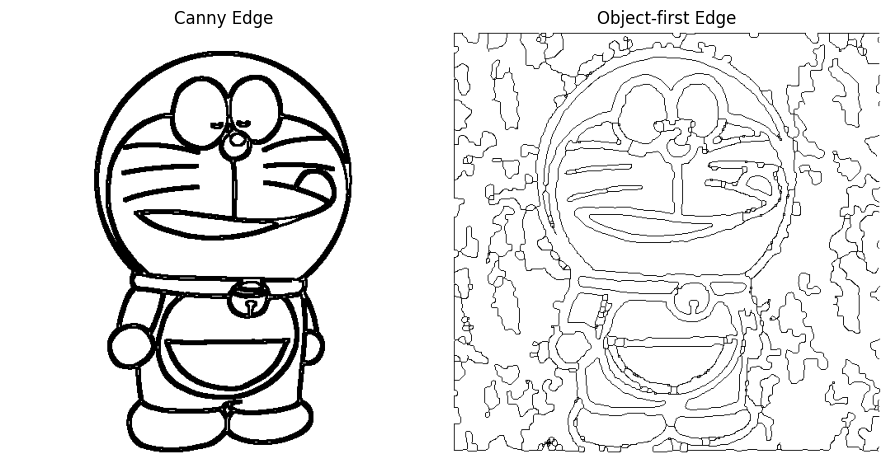

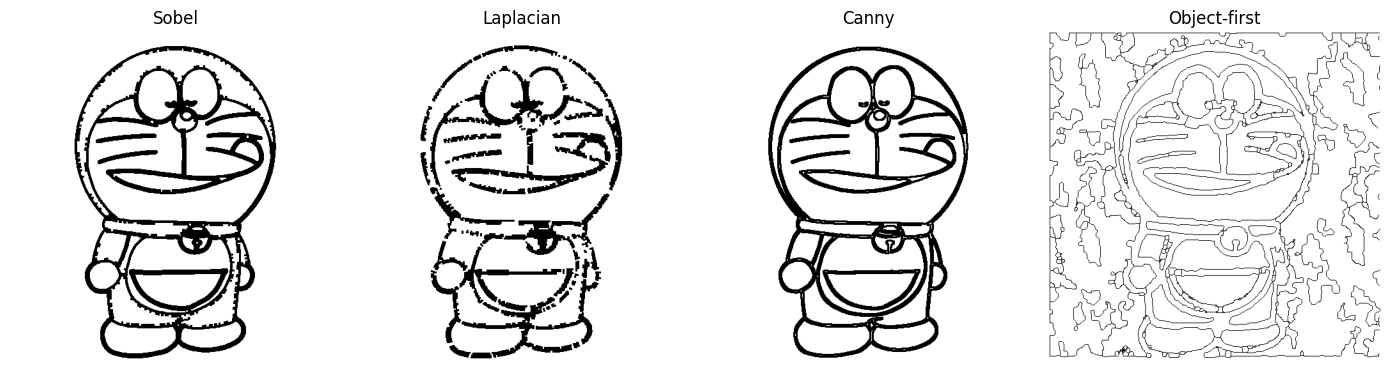

WindowsPath('presentation/slide04_edge_methods_comparison.png')

In [7]:
# Slide 04: Edge 방식 trade-off
save_named("slide04_canny_edge.png", canny_line)
save_named("slide04_object_first_edge.png", object_line)
save_named("slide04_sobel_edge.png", sobel_line)
save_named("slide04_laplacian_edge.png", lap_line)
save_compare(
    "slide04_edge_tradeoff_canny_vs_object_first.png",
    [("Canny Edge", canny_line), ("Object-first Edge", object_line)],
    cols=2,
    figsize=(9, 5),
    cmap="gray",
)
save_compare(
    "slide04_edge_methods_comparison.png",
    [("Sobel", sobel_line), ("Laplacian", lap_line), ("Canny", canny_line), ("Object-first", object_line)],
    cols=4,
    figsize=(14, 4),
    cmap="gray",
)

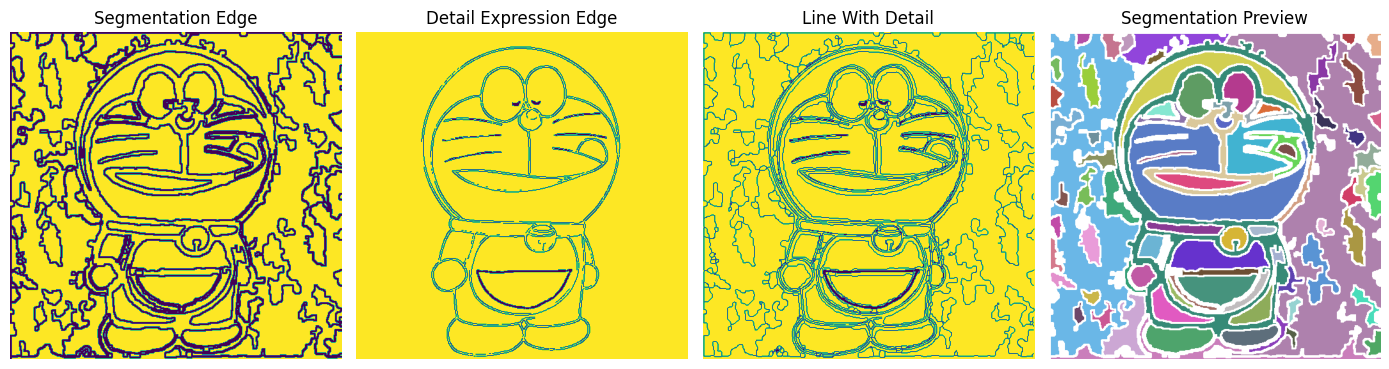

WindowsPath('presentation/slide05_segmentation_vs_detail.png')

In [8]:
# Slide 05: Segmentation과 detail edge 분리
save_named("slide05_segmentation_edge.png", segmentation_line_image)
save_named("slide05_detail_expression_edge.png", detail_line)
save_named("slide05_line_with_detail.png", line_with_detail)
save_named("slide05_segmentation_preview.png", region_preview)
save_compare(
    "slide05_segmentation_vs_detail.png",
    [
        ("Segmentation Edge", segmentation_line_image),
        ("Detail Expression Edge", detail_line),
        ("Line With Detail", line_with_detail),
        ("Segmentation Preview", region_preview),
    ],
    cols=4,
    figsize=(14, 4),
)

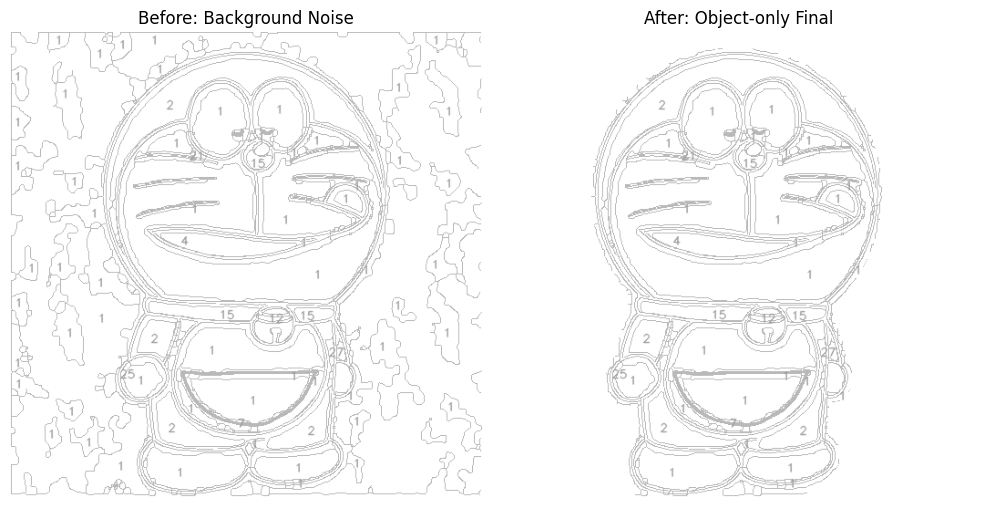

Saved presentation assets:
presentation\slide01_final_numbered_coloringbook.png
presentation\slide01_original.png
presentation\slide01_title_before_after.png
presentation\slide02_01_input.png
presentation\slide02_02_color_simplification.png
presentation\slide02_03_object_first_edge.png
presentation\slide02_04_segmentation.png
presentation\slide02_05_final.png
presentation\slide02_pipeline_overview.png
presentation\slide03_color_tradeoff_k10_k30_k50.png
presentation\slide03_k10_color_simplification.png
presentation\slide03_k30_color_simplification.png
presentation\slide03_k50_color_simplification.png
presentation\slide04_canny_edge.png
presentation\slide04_edge_methods_comparison.png
presentation\slide04_edge_tradeoff_canny_vs_object_first.png
presentation\slide04_laplacian_edge.png
presentation\slide04_object_first_edge.png
presentation\slide04_sobel_edge.png
presentation\slide05_detail_expression_edge.png
presentation\slide05_line_with_detail.png
presentation\slide05_segmentation_edge

In [9]:
# Slide 06: 최종 개선점 Before / After
save_named("slide06_before_background_noise.png", before_noisy)
save_named("slide06_after_clean_object_only.png", after_clean)
save_named("slide06_colored_by_labels_numbered.png", colored_by_labels_numbered)
save_compare(
    "slide06_before_after_final.png",
    [("Before: Background Noise", before_noisy), ("After: Object-only Final", after_clean)],
    cols=2,
    figsize=(10, 5),
)
print("Saved presentation assets:")
for p in sorted(PRESENTATION_DIR.glob("*.png")):
    print(p)